General Remarks

1- Here θ corresponds to the angle between the uniform superposition of computational bases and the superposition of non-solution states.

2- QSearch algorithm is taken from arXiv:2203.04975 [quant-ph].

libraries

In [103]:
using Plots, Random, StatsPlots
using Distributions, StatsBase, JLD2

Monte Carlo simulations of Grover's & classical searches

In [104]:
function GroverSimulator(N::Int, tActual::Int, j::Int)::Bool
    theta = asin(sqrt(tActual / N))
    pSuccess = sin((2 * j + 1) * theta)^2
    return rand() <= pSuccess
end

function ClassicalSampler(tActual::Int64, N::Int64, NCsamples::Int64)
    k = 0
    while k <= NCsamples
        if rand() <= tActual/N
            return true, k + 1
        end
        k += 1
    end
    return false
end;


QSearch initalizations

In [105]:
#number of classical sampling before starting Grover iterations 
NCsamples = 130

# the bound to the total number of Grover iterations before reseting λ and m, i.e. the interval the candidate number of iterations is drawn from.
α =  9.2;

QSearch Simulator

In [106]:
function QSearch(tActual::Int64, NN::Int64, NCsamples::Int64)
    
    samplingResult = ClassicalSampler(tActual, NN, NCsamples)
    
    if samplingResult[1]  
        return samplingResult[2]
    end

    Qmax = α * sqrt(NN)
    r = 0
    queries = NCsamples

    while true 
        λ = 6/5
        m =  6/5
        Qsum = 0
        j = Int(rand(0:floor(m)))
            
        while Qsum + j <= Qmax
            measOutcome = GroverSimulator(NN, tActual, j)
            Qsum += j + 1

            #the number of calls to the classical oracle for j Grover iterations plus measurement verification
            queries += 2*j + 1
            
            if measOutcome 
               return queries 
            else  
                m = min(λ * m, sqrt(NN))  
                j = Int(rand(0:floor(m)))
            end
        end
    end
end;


Particle-Guided Grover's Search simulator

In [107]:
function BayesDecision(t::Vector{Int}, w::Vector{Float64}, N::Int)::Int
    maxP = 0.0
    jChosen = 1
    for j in 1:ceil(Int, sqrt(N))
        pSuccess = sum(w[i] * sin((2*j + 1)*asin(sqrt(t[i]/N)))^2 for i in eachindex(t))/j
        if pSuccess > maxP
            maxP = pSuccess
            jChosen = j
        end
    end
    return jChosen
end

function Resample(t::Vector{Int}, w::Vector{Float64})
    L = length(t)
    indices = rand(Categorical(w), L)
    tResampled = t[indices]
    wResampled = fill(1.0 / L, L)
    return tResampled, wResampled
end


function PosteriorEstimator(t::Vector{Int}, w::Vector{Float64}, j::Int, N::Int)
    L = length(t)
    wNew = similar(w) #similar to w, but uninitialized.
    for i in 1:L 
        theta = asin(sqrt(t[i] / N))
        likelihood = cos((2 * j + 1) * theta)^2
        wNew[i] = w[i] * likelihood
    end
    total = sum(wNew)
    wNew ./= total

    # Resampling step (if needed)
    neff = 1 / sum(wNew .^ 2)
    if neff < L / 10
    t, wNew = Resample(t, wNew)
    end

    return t, wNew
end


function ParticleGuidedGrover(N::Int, tActual::Int, prior_sampler::Function, L::Int)
    k = 0
    queries = 0
    measOutcome = false
    j = 1

    # initialize particles and weights using Monte Carlo sampling (done by prior_sampler function)
    t = [prior_sampler() for _ in 1:L]
    particles_history = [copy(t)]
        
    w = fill(1.0 / L, L)
    weight_history = [copy(w)]

    while !measOutcome
        if k == 0
            j = BayesDecision(t, w, N)
        else
            t, w = PosteriorEstimator(t, w, j, N)
            j = BayesDecision(t, w, N)
            push!(particles_history, copy(t))
            push!(weight_history, copy(w))
        end

        measOutcome = GroverSimulator(N, tActual, j)
        queries += 2j + 1
        k += 1
    end
    return queries, particles_history, weight_history
end;


Plotting how the particles evolve under PGGS 

In [108]:
function plot_particle_weight_evolution(particles_history, weight_history)
    steps = length(particles_history)
    L = length(particles_history[1])

    xs = Int[]
    ys = Int[]
    sizes = Float64[]

    for k in 1:steps
        particles = particles_history[k]
        weights = weight_history[k]
        for i in 1:L
            push!(xs, k)                     # step index
            push!(ys, particles[i])          # particle value
            push!(sizes, weights[i] * 500)  # marker size scaled by weight
        end
    end

    scatter(ys, xs, markersize=sizes,
            xlabel="t Value",
            ylabel="Grover's Cycle No.",
            title="Particles Evolution",
            legend=false,
            color=:turquoise,
            alpha=0.8,
    yrange = [0,steps+1])
end;


******************** Input Setting ************************

In [109]:
N = Int(1E6)    # the size of the search space
L = 100         # the number of particles used by PGGS
tsample = 1000; # number of samples for actual t (true number of solutions in the search problem) 


Benchmarking PGGS against QSearch

In [116]:
function benchmark_PGGS_vs_QSearch(L::Int64; tsample::Int64)
    
    range = Int64[]

    for j in 1:ceil(log10(N))
        push!(range,  Int(10^(j-1)) )
    end
    fvalues = Vector{Vector{Float64}}()
    all_q_valuesPGGS = Vector{Vector{Int64}}()
    all_q_valuesQS = Vector{Vector{Int64}}()
    
    
    for sigma in range
        
        # Store (t/N, query) pairs inside this loop
        t_over_N_vals = Float64[]
        queries_pggs_temp = Int64[]
        queries_qs_temp = Int64[]
        
        # uniform prior
        #prior_dist  = DiscreteUniform(1, ceil(Int, N/4))
        
        # unimodal prior  
        prior_dist = truncated(Normal(10, sigma), 1, N/4)
        
        # bimodal prior (steps 1 & 2)
        # 1- Truncated Gaussian Mixture
        #d1 = Truncated(Normal(500, 100),  1, N/4)
        #d2 = Truncated(Normal(10, 100),  1, N/4)
        # 2- Create a mixture model (weights sum to 1)
        #prior_dist = MixtureModel([d1, d2], [0.5, 0.5])
        
        # sampling an integer according to prior_dist which is ensured to be >=1 and <=N/4 by the clamp function. 
        prior_sampler = () -> clamp(round(Int, rand(prior_dist)), 1, ceil(Int, N/4)) 

        # to plot the zoomed-in figure in the regime t/N ∼ 0, we need to sample t with rejection
        #prior_sampler = () -> begin
         #   t = 0
          #      while true
           #         t = clamp(round(Int, rand(prior_dist)), 1, ceil(Int, N/4))
            #        if t / N ≤ 0.0001
             #           return t
              #      end
               # end
        #end

        # sampling the actual t values according to the prior distribution. 
        # For mismatching prior case, a different distribution should be used here.
        t_values = [prior_sampler() for _ in 1:tsample]
        

        for t_actual in t_values
        
            q_pggs, _ = ParticleGuidedGrover(N, t_actual, prior_sampler, L)
            q_qs = QSearch(t_actual, N, NCsamples)
           

            # Store the number of queries for each algorithm along with the fraction t/N
            push!(t_over_N_vals, t_actual / N)
            push!(queries_pggs_temp, q_pggs) 
            push!(queries_qs_temp, q_qs) 
            
      
        end

        push!(fvalues, t_over_N_vals)
        push!(all_q_valuesPGGS, queries_pggs_temp) 
        push!(all_q_valuesQS, queries_qs_temp) 

    end

    return (range, fvalues, all_q_valuesPGGS, all_q_valuesQS)

end;




Plotting the average queries  

In [117]:
function plot(L::Int64; tsample::Int64)
    
    range, fvalues, all_q_valuesPGGS, all_q_valuesQS = benchmark_PGGS_vs_QSearch(L; tsample);
    plt = scatter()  # initialize empty plot

    avg_q_valuesPGGS = Vector{Float64}()
    avg_q_valuesQS = Vector{Float64}()
    

    fvals_flattened = vcat(fvalues...)
    uniq_f = sort(unique(fvals_flattened))
 
    q_QS_flattened = vcat(all_q_valuesQS...)
    mean_qs = [mean(q_QS_flattened[fvals_flattened .== r]) for r in uniq_f]
    
    scatter!(plt, uniq_f, mean_qs, label = "QSearch",  markersize=3, alpha=1, marker=:diamond, mc=:red) 

    for k in 1:length(range)
        
        # Unique sorted ratios
        uniq_ratios = sort(unique(fvalues[k]))
                
        # Compute mean queries for each unique t/N ratio 
        mean_pggs = [mean(all_q_valuesPGGS[k][fvalues[k] .== r]) for r in uniq_ratios]
                  
        # plot for each ratio  
        scatter!(plt, uniq_ratios, mean_pggs, label = "PGGS, σ =$(range[k])",  markersize=3, alpha=1)   

        # Compute overall averages for each simulation, i.e. range value.
        overall_mean_pggs = mean(all_q_valuesPGGS[k])
        overall_mean_qs = mean(all_q_valuesQS[k])

        # store the overall averages
        push!(avg_q_valuesPGGS, overall_mean_pggs)
        push!(avg_q_valuesQS, overall_mean_qs)
       
    end
    
    xlabel!("t / N")
    ylabel!("Average Query Count")
    title!("Avg Queries vs t/N") 
    display(plt)
    #savefig("differentdistsComparison-N$N-ts$tsample-L$L.pdf") 

    #bar plot 
    ctgs = ["PGGS", "QS"]
    labels = string.(range[1:length(avg_q_valuesPGGS)]) 

    plot_ctgs = repeat(ctgs, inner = size(labels,1) ) 
    plot_labels = repeat(labels, outer = size(ctgs,1) ) 
    
    # Combine into a matrix with shape N×2 (rows = entries, columns = series)
    all_values = hcat(avg_q_valuesPGGS, avg_q_valuesQS)
    

    barplt = groupedbar(plot_labels, all_values; group = plot_ctgs, ylabel= "Average Query Count", xlabel="σ")  
    display(barplt)
    #savefig("averageComparison-N$N-ts$tsample-L$L.pdf")
    
end;

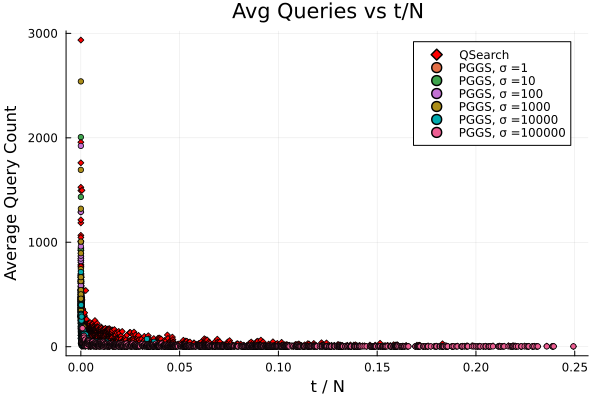

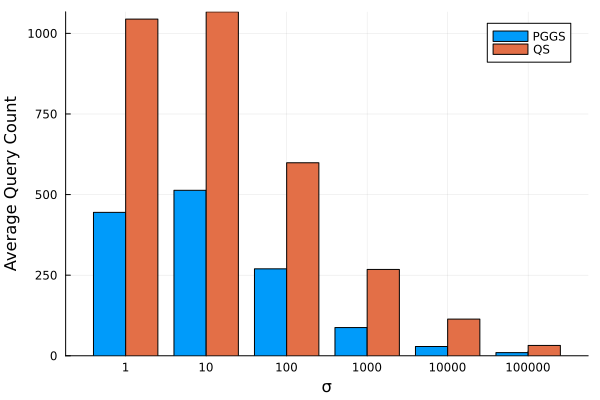

In [118]:
plot(L; tsample)

ploting prior


In [120]:
function plot_binned_pmf(d::Distribution, nbins::Int=100)
    samples = rand(d, 100000)  # sample to approximate PMF
    bin_edges = range(extrema(samples)..., length=nbins+1)
    h = fit(Histogram, samples, bin_edges)

    bar(h.edges[1][1:end-1], h.weights ./ sum(h.weights),
        label="",
        xlabel="t",
        ylabel="Probability",
        title="PMF Approximation")
end;

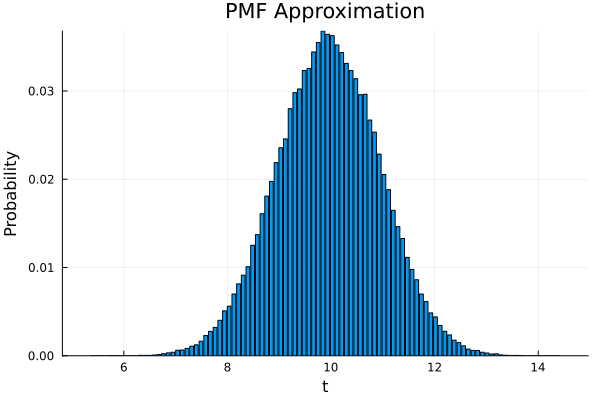

In [124]:
prior_dist = truncated(Normal(10, 1), 1, N/4)
plot_binned_pmf(prior_dist, 100)